In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier


In [2]:
DATA_FILE = "telco_churn.csv"
TARGET_COL = "Churn"

# Features
NUMERICAL_FEATURES = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

CATEGORICAL_FEATURES = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [3]:
# Model
MODEL_NAME = "xgboost_churn"
MODEL_VERSION = "1.0.0"
RANDOM_STATE = 42
TEST_SIZE = 0.2

# XGBoost hyperparameters
XGBOOST_PARAMS = {
    "max_depth": 6,
    "learning_rate": 0.1,
    "n_estimators": 200,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "scale_pos_weight": 3,  # Gestion déséquilibre (73.5/26.5)
    "random_state": RANDOM_STATE,
}

# Thresholds
CHURN_THRESHOLD = 0.5  # Probabilité seuil pour prédire churn
HIGH_RISK_THRESHOLD = 0.7  # Seuil pour risque élevé

# MLflow
MLFLOW_TRACKING_URI = "./mlruns"
EXPERIMENT_NAME = "churn_prediction"

# API
API_TITLE = "Churn Prediction API"
API_VERSION = "1.0.0"
API_HOST = "0.0.0.0"
API_PORT = 8000

In [4]:
df = pd.read_csv("telco_churn.csv")
# Nettoyage TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remplacer les NaN (clients très récents, tenure = 0)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Target en binaire
df[TARGET_COL] = df[TARGET_COL].map({"Yes": 1, "No": 0})


In [5]:
X = df[NUMERICAL_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET_COL]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUMERICAL_FEATURES),
        ("cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ), CATEGORICAL_FEATURES)
    ]
)


In [8]:
xgb_model = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=3,
    random_state=RANDOM_STATE,
    use_label_encoder=False
)


In [9]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", xgb_model)
])


In [10]:
pipeline.fit(X_train, y_train)


c:\Users\User\Downloads\pimp-your-portfolio\01-churn-prediction-telecom\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:06:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [11]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= CHURN_THRESHOLD).astype(int)


In [12]:
print(classification_report(y_test, y_pred))
print("AUC ROC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409

AUC ROC: 0.8309927923738667


In [13]:
def create_features(df):
    df = df.copy()

    # 1. Ratio prix / ancienneté
    df["price_tenure_ratio"] = df["MonthlyCharges"] / (df["tenure"] + 1)

    # 2. Nombre de services souscrits
    service_cols = [
        "PhoneService", "InternetService", "OnlineSecurity",
        "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies"
    ]
    df["total_services"] = (df[service_cols] == "Yes").sum(axis=1)

    # 3. Internet sans protection
    df["internet_no_protection"] = (
        (df["InternetService"] != "No") &
        (df["OnlineSecurity"] == "No") &
        (df["TechSupport"] == "No")
    ).astype(int)

    # 4. Segment d’ancienneté
    df["tenure_segment"] = pd.cut(
        df["tenure"],
        bins=[0, 12, 24, 60, 100],
        labels=["<1yr", "1-2yr", "2-5yr", ">5yr"]
    )

   
    return df


In [14]:

df = pd.read_csv("telco_churn.csv")
# Nettoyage
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df[TARGET_COL] = df[TARGET_COL].map({"Yes": 1, "No": 0})

# Feature engineering
df = create_features(df)

# Séparation
X = df.drop(columns=[TARGET_COL, "customerID"], errors="ignore")
y = df[TARGET_COL]

# Encodage catégoriel
X = pd.get_dummies(X, drop_first=True)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)


In [15]:
from xgboost import XGBClassifier

model = XGBClassifier(
    **XGBOOST_PARAMS
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= CHURN_THRESHOLD).astype(int)


In [16]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("AUC ROC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409

AUC ROC: 0.8327081557260584


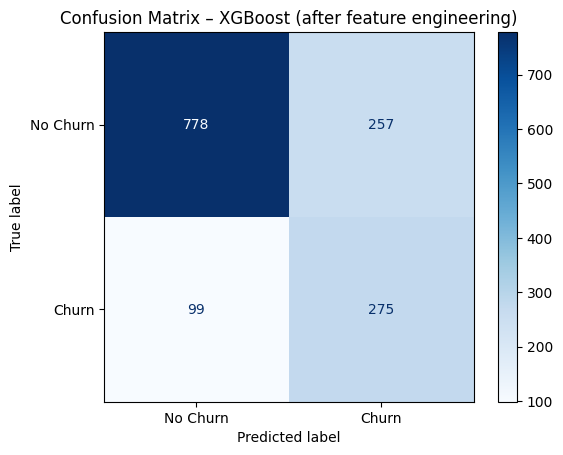

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilités de churn
y_proba = model.predict_proba(X_test)[:, 1]

# Prédictions binaires (seuil 0.5)
y_pred = (y_proba >= 0.5).astype(int)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Affichage
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – XGBoost (after feature engineering)")
plt.show()
